In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf


**Download the Dataset**

In [ ]:
import kagglehub

# Downloads the dataset and returns the local path (cached after first run)
DATA_ROOT = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")
print("Dataset downloaded to:", DATA_ROOT)


Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Dataset downloaded to: /kaggle/input/brain-tumor-mri-dataset


In [ ]:
# Locate the Training / Testing folders (path structure can vary slightly by kagglehub version)
for root, dirs, files in os.walk(DATA_ROOT):
    depth = root.replace(DATA_ROOT, '').count(os.sep)
    if depth < 2:
        print(root, '->', dirs)

TRAIN_DIR = os.path.join(DATA_ROOT, "Training")
TEST_DIR = os.path.join(DATA_ROOT, "Testing")

assert os.path.isdir(TRAIN_DIR), f"Couldn't find Training folder, check the printed structure above and fix TRAIN_DIR"
assert os.path.isdir(TEST_DIR), f"Couldn't find Testing folder, check the printed structure above and fix TEST_DIR"

print("Classes found:", sorted(os.listdir(TRAIN_DIR)))


/kaggle/input/brain-tumor-mri-dataset -> ['Training', 'Testing']
/kaggle/input/brain-tumor-mri-dataset/Training -> ['pituitary', 'notumor', 'meningioma', 'glioma']
/kaggle/input/brain-tumor-mri-dataset/Testing -> ['pituitary', 'notumor', 'meningioma', 'glioma']
Classes found: ['glioma', 'meningioma', 'notumor', 'pituitary']


**Load the data**

In [ ]:
IMG_SIZE = (150, 150)
BATCH_SIZE = 32
SEED = 42

train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

class_names = train_dataset.class_names
num_classes = len(class_names)
print("Class names:", class_names)
print("Num classes:", num_classes)


Found 5600 files belonging to 4 classes.
Using 4480 files for training.
Found 5600 files belonging to 4 classes.
Using 1120 files for validation.
Found 1600 files belonging to 4 classes.
Class names: ['glioma', 'meningioma', 'notumor', 'pituitary']
Num classes: 4


In [ ]:
# Performance optimizations (same idea as your cats-vs-dogs notebook)
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().shuffle(1000).prefetch(AUTOTUNE)
validation_dataset = validation_dataset.cache().prefetch(AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(AUTOTUNE)


**Data Augmentation**

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
], name="data_augmentation")


**Transfer Learning Pipeline**

In [ ]:
def build_and_train(base_model_fn, preprocess_fn, model_name,
                     img_size=IMG_SIZE, num_classes=num_classes,
                     head_epochs=8, fine_tune_epochs=6,
                     fine_tune_at_fraction=0.8):
    """
    base_model_fn: e.g. tf.keras.applications.VGG19
    preprocess_fn: e.g. tf.keras.applications.vgg19.preprocess_input
    model_name: label for printing/plots
    fine_tune_at_fraction: fraction of base model layers to KEEP frozen during fine-tuning
    """
    print(f"\n{'='*60}\nBuilding {model_name}\n{'='*60}")

    base_model = base_model_fn(
        input_shape=img_size + (3,),
        include_top=False,
        weights="imagenet"
    )
    base_model.trainable = False

    inputs = tf.keras.Input(shape=img_size + (3,))
    x = data_augmentation(inputs)
    x = preprocess_fn(x)
    x = base_model(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(256, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

    model = tf.keras.Model(inputs, outputs, name=model_name)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    print(f"--- Phase 1: training classification head (base frozen) ---")
    history_head = model.fit(
        train_dataset,
        validation_data=validation_dataset,
        epochs=head_epochs,
        verbose=2
    )

    # Phase 2: fine-tune the top layers of the base model
    print(f"--- Phase 2: fine-tuning top layers of {model_name} ---")
    base_model.trainable = True
    fine_tune_at = int(len(base_model.layers) * fine_tune_at_fraction)
    for layer in base_model.layers[:fine_tune_at]:
        layer.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    history_fine = model.fit(
        train_dataset,
        validation_data=validation_dataset,
        epochs=fine_tune_epochs,
        verbose=2
    )

    # Combine both phases' histories for plotting full training curves
    combined_history = {}
    for key in history_head.history:
        combined_history[key] = history_head.history[key] + history_fine.history[key]

    # Final evaluation on the held-out test set
    test_loss, test_acc = model.evaluate(test_dataset, verbose=0)
    print(f"{model_name} — Test accuracy: {test_acc:.4f}, Test loss: {test_loss:.4f}")

    return model, combined_history, test_acc, test_loss


**Train all three Models**

In [ ]:
configs = [
    ("VGG19", tf.keras.applications.VGG19, tf.keras.applications.vgg19.preprocess_input),
    ("InceptionV3", tf.keras.applications.InceptionV3, tf.keras.applications.inception_v3.preprocess_input),
    ("ResNet152", tf.keras.applications.ResNet152, tf.keras.applications.resnet.preprocess_input),
]

trained_models = {}
histories = {}
results = {}

for name, base_fn, preprocess_fn in configs:
    model, history, test_acc, test_loss = build_and_train(base_fn, preprocess_fn, name)
    trained_models[name] = model
    histories[name] = history
    results[name] = {
        "final_train_acc": history["accuracy"][-1],
        "final_val_acc": history["val_accuracy"][-1],
        "test_acc": test_acc,
        "final_train_loss": history["loss"][-1],
        "final_val_loss": history["val_loss"][-1],
        "test_loss": test_loss,
    }

print("\nAll models trained.")



Building VGG19
80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
--- Phase 1: training classification head (base frozen) ---
Epoch 1/8
140/140 - 35s - 253ms/step - accuracy: 0.7199 - loss: 1.0763 - val_accuracy: 0.8143 - val_loss: 0.5215
Epoch 2/8
140/140 - 13s - 94ms/step - accuracy: 0.8172 - loss: 0.4995 - val_accuracy: 0.8589 - val_loss: 0.4155
Epoch 3/8
140/140 - 13s - 95ms/step - accuracy: 0.8513 - loss: 0.4092 - val_accuracy: 0.8848 - val_loss: 0.3705
Epoch 4/8
140/140 - 13s - 96ms/step - accuracy: 0.8679 - loss: 0.3617 - val_accuracy: 0.8580 - val_loss: 0.4603
Epoch 5/8
140/140 - 14s - 97ms/step - accuracy: 0.8766 - loss: 0.3309 - val_accuracy: 0.8750 - val_loss: 0.3382
Epoch 6/8
140/140 - 14s - 98ms/step - accuracy: 0.8911 - loss: 0.2898 - val_accuracy: 0.8875 - val_loss: 0.3295
Epoch 7/8
140/140 - 14s - 100ms/step - accuracy: 0.8958 - loss: 0.2773 - val_accuracy: 0.8839 - val_loss: 0.3387
Epoch 8/8
140/140 - 14s - 101ms/step - accuracy: 0.8938 - loss: 0.2741 - val_accuracy: 

**Results Summary**

In [ ]:
import pandas as pd

results_df = pd.DataFrame(results).T
results_df = results_df[["final_train_acc", "final_val_acc", "test_acc",
                          "final_train_loss", "final_val_loss", "test_loss"]]
results_df.style.format("{:.4f}")


,final_train_acc,final_val_acc,test_acc,final_train_loss,final_val_loss,test_loss
VGG19,0.9629,0.9214,0.8875,0.0964,0.2944,0.7116
InceptionV3,0.9114,0.9045,0.8450,0.2539,0.2659,0.4723
ResNet152,0.9676,0.9214,0.8656,0.0905,0.2675,0.6679


**Comparison Bar Chart**

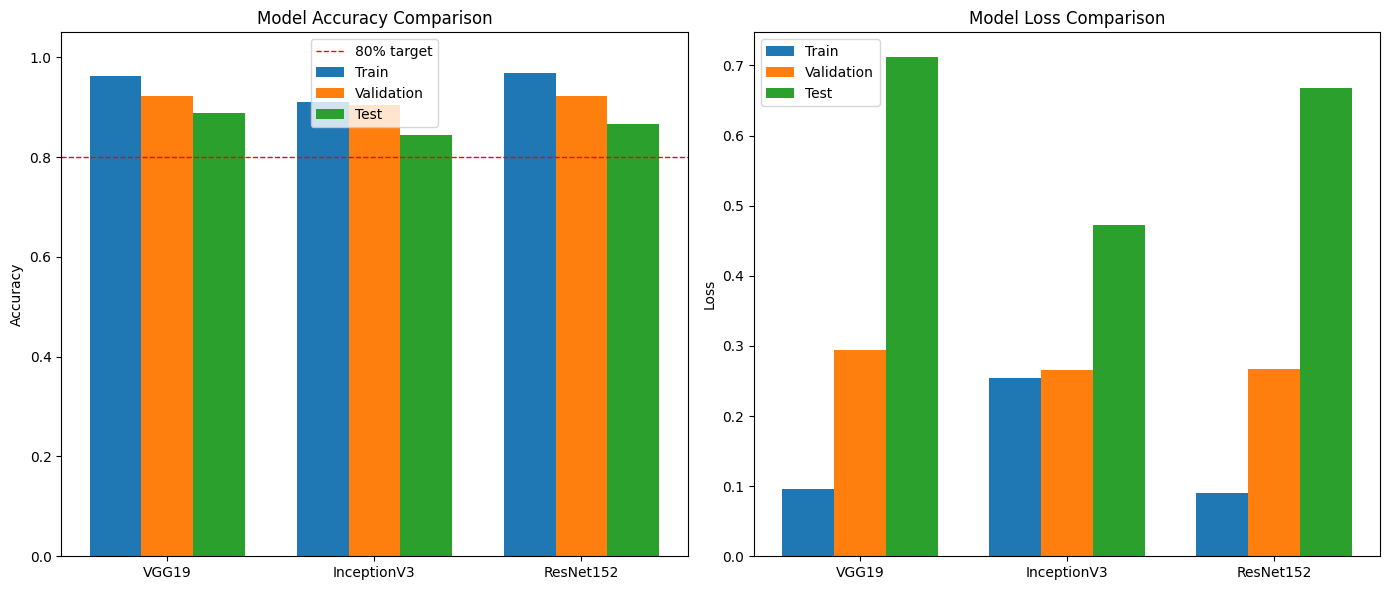

In [ ]:
labels = list(results.keys())
x = np.arange(len(labels))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Accuracy comparison ---
train_accs = [results[m]["final_train_acc"] for m in labels]
val_accs = [results[m]["final_val_acc"] for m in labels]
test_accs = [results[m]["test_acc"] for m in labels]

axes[0].bar(x - width, train_accs, width, label="Train")
axes[0].bar(x, val_accs, width, label="Validation")
axes[0].bar(x + width, test_accs, width, label="Test")
axes[0].axhline(0.80, color="red", linestyle="--", linewidth=1, label="80% target")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Model Accuracy Comparison")
axes[0].set_ylim(0, 1.05)
axes[0].legend()

# --- Loss comparison ---
train_losses = [results[m]["final_train_loss"] for m in labels]
val_losses = [results[m]["final_val_loss"] for m in labels]
test_losses = [results[m]["test_loss"] for m in labels]

axes[1].bar(x - width, train_losses, width, label="Train")
axes[1].bar(x, val_losses, width, label="Validation")
axes[1].bar(x + width, test_losses, width, label="Test")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_ylabel("Loss")
axes[1].set_title("Model Loss Comparison")
axes[1].legend()

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150)
plt.show()
